# Preprocessing external dataset: Cantoni et al. (2025)

In [ ]:
import os
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from scipy import sparse

np.random.seed(42)

Source data downloaded from Synapse (accession syn51730532)

# Load and preprocess data

Load raw counts and subset to the selected studies/samples based on:
1. Studies with paired PBMC and CSF samples for most donors (Cantoni et al. 2025, Pappalardo et al. 2022, Ramesh et al. 2020, Schafflick et al. 2020)
2. Samples from untreated MS/CIS or healthy controls only

In [2]:
adata = sc.read_h5ad("../data/processed/external/cantoni/source/atlas_raw_counts.h5ad")
adata.obs["study_short"][adata.obs["study_short"] == "dbgap"] = "dbGaP"
adata = adata[adata.obs["study_short"].isin(["All_WUSTL", "dbGaP", "GSE133028", "GSE138266"]) & adata.obs["disease"].isin(["MS", "CIS", "HC"]) & (~adata.obs["treatment"].isin(["unknown", "previously treated", "active treatment"])), :].copy()

Add sample pairing information to metadata (matched PBMC and CSF samples from the same donor)

In [3]:
md = pd.read_csv("../data/processed/external/cantoni/source/cantoni_untreated_ms_hc_sample_metadata.tsv", sep="\t", index_col=None)
mapper = {k: v for k, v in zip(md["sample"], md["sample_pair"])}
adata.obs["sample_pair"] = adata.obs["sample"].map(mapper)

Standardise gene names across datasets and aggregate counts for alias genes in original count matrix

In [4]:
translation = pd.read_csv("../data/processed/external/cantoni/source/cantoni_genes_translation.tsv", sep="\t", header=0, index_col="original_gene_symbol")
translation.index.name = None

adata = adata[:, translation.index].copy()
adata.var = translation.copy()

grouped = translation.groupby('ensembl_id')
n_original_genes = adata.n_vars
unique_ensembl_ids = translation['ensembl_id'].unique()
n_unique_genes = len(unique_ensembl_ids)
ensembl_to_new_idx = {ensembl_id: i for i, ensembl_id in enumerate(unique_ensembl_ids)}

row_indices = []
col_indices = []
data = []

for old_idx, (ensembl_id, gene_symbol) in enumerate(zip(translation['ensembl_id'], translation['gene_symbol'])):
    new_idx = ensembl_to_new_idx[ensembl_id]
    row_indices.append(new_idx)
    col_indices.append(old_idx)
    data.append(1.0)

aggregation_matrix = sparse.csr_matrix(
    (data, (row_indices, col_indices)), 
    shape=(n_unique_genes, n_original_genes)
)

X_aggregated = (aggregation_matrix @ adata.X.T).T

new_var = pd.DataFrame(index=unique_ensembl_ids)
new_var['ensembl_id'] = unique_ensembl_ids
new_var['gene_symbol'] = [grouped.get_group(ensembl_id)['gene_symbol'].iloc[0] 
                          for ensembl_id in unique_ensembl_ids]
new_var['gene_type'] = [grouped.get_group(ensembl_id)['gene_type'].iloc[0]
                        for ensembl_id in unique_ensembl_ids]
new_var.index = new_var['gene_symbol']
new_var.index.name = None

adata = ad.AnnData(
    X=X_aggregated,
    obs=adata.obs.copy(),
    var=new_var
)
adata.var_names_make_unique()

sc.pp.filter_genes(adata, min_cells=1)

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
# Store raw counts for use with starCAT
adata.raw = adata
adata

AnnData object with n_obs × n_vars = 184296 × 18841
    obs: 'author', 'study_short', 'study_full_name', 'sample', 'sex', 'organ', 'disease', 'disease_group', 'age', 'treatment', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'percent.mito_log10', 'nCount_RNA_log10', 'nFeature_RNA_log10', 'nCount_RNA_log2', 'nFeature_RNA_log2', 'scaled_mito', 'scaled_nCount_RNA', 'dataset', 'cell_type', 'disease_group_comb', 'sample_pair'
    var: 'ensembl_id', 'gene_symbol', 'gene_type', 'n_cells'

# Normalise, find variable features across datasets and integrate

Load cell cycle genes (plain text files with one gene symbol per line containing the genes from Seurat `cc.genes$g2m.genes` and `cc.genes$s.genes`)

In [ ]:
with open("../data/ref/genes/g2m_genes.txt") as f:
    g2m_genes = f.read().splitlines()
    g2m_genes = [gene for gene in g2m_genes if gene in adata.var_names]

with open("../data/ref/genes/s_genes.txt") as f:
    s_genes = f.read().splitlines()
    s_genes = [gene for gene in s_genes if gene in adata.var_names]

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)
sc.pp.highly_variable_genes(adata, n_top_genes=5000, batch_key="sample")
# Exclude mitochondrial and ribosomal genes from highly variable features
mito_genes = adata.var_names.str.startswith("MT-")
ribo_genes = adata.var_names.str.startswith(("RPS", "RPL"))
exclude_genes = mito_genes | ribo_genes
adata.var.loc[exclude_genes, "highly_variable"] = False
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.regress_out(adata, keys=["percent.mito", "S_score", "G2M_score"], n_jobs=16)
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, n_comps=50, svd_solver="arpack")
sc.external.pp.harmony_integrate(adata, key=["sample", "study_short"], max_iter_harmony=50)

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
2025-10-07 21:57:33,585 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-07 21:57:42,885 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-07 21:57:43,479 - harmonypy - INFO - Iteration 1 of 50
2025-10-07 21:58:41,805 - harmonypy - INFO - Iteration 2 of 50
2025-10-07 21:59:39,089 - harmonypy - INFO - Iteration 3 of 50
2025-10-07 22:00:38,218 - harmonypy - INFO - Iteration 4 of 50
2025-10-07 22:01:39,725 - harmonypy - INFO - Iteration 5 of 50
2025-10-07 22:02:41,342 - harmonypy - INFO - Iteration 6 of 50
2025-10-07 22:03:42,069 - harmonypy - INFO - Iteration 7 of 50
2025-10-07 22:04:22,582 - harmonypy - INFO - Iteration 8 of 50
2025-10-07 22:04:51,894 - harmo

In [8]:
sc.pp.neighbors(adata, transformer=AnnoyTransformer(n_neighbors=30, metric="angular"), use_rep="X_pca_harmony")
sc.tl.umap(adata)

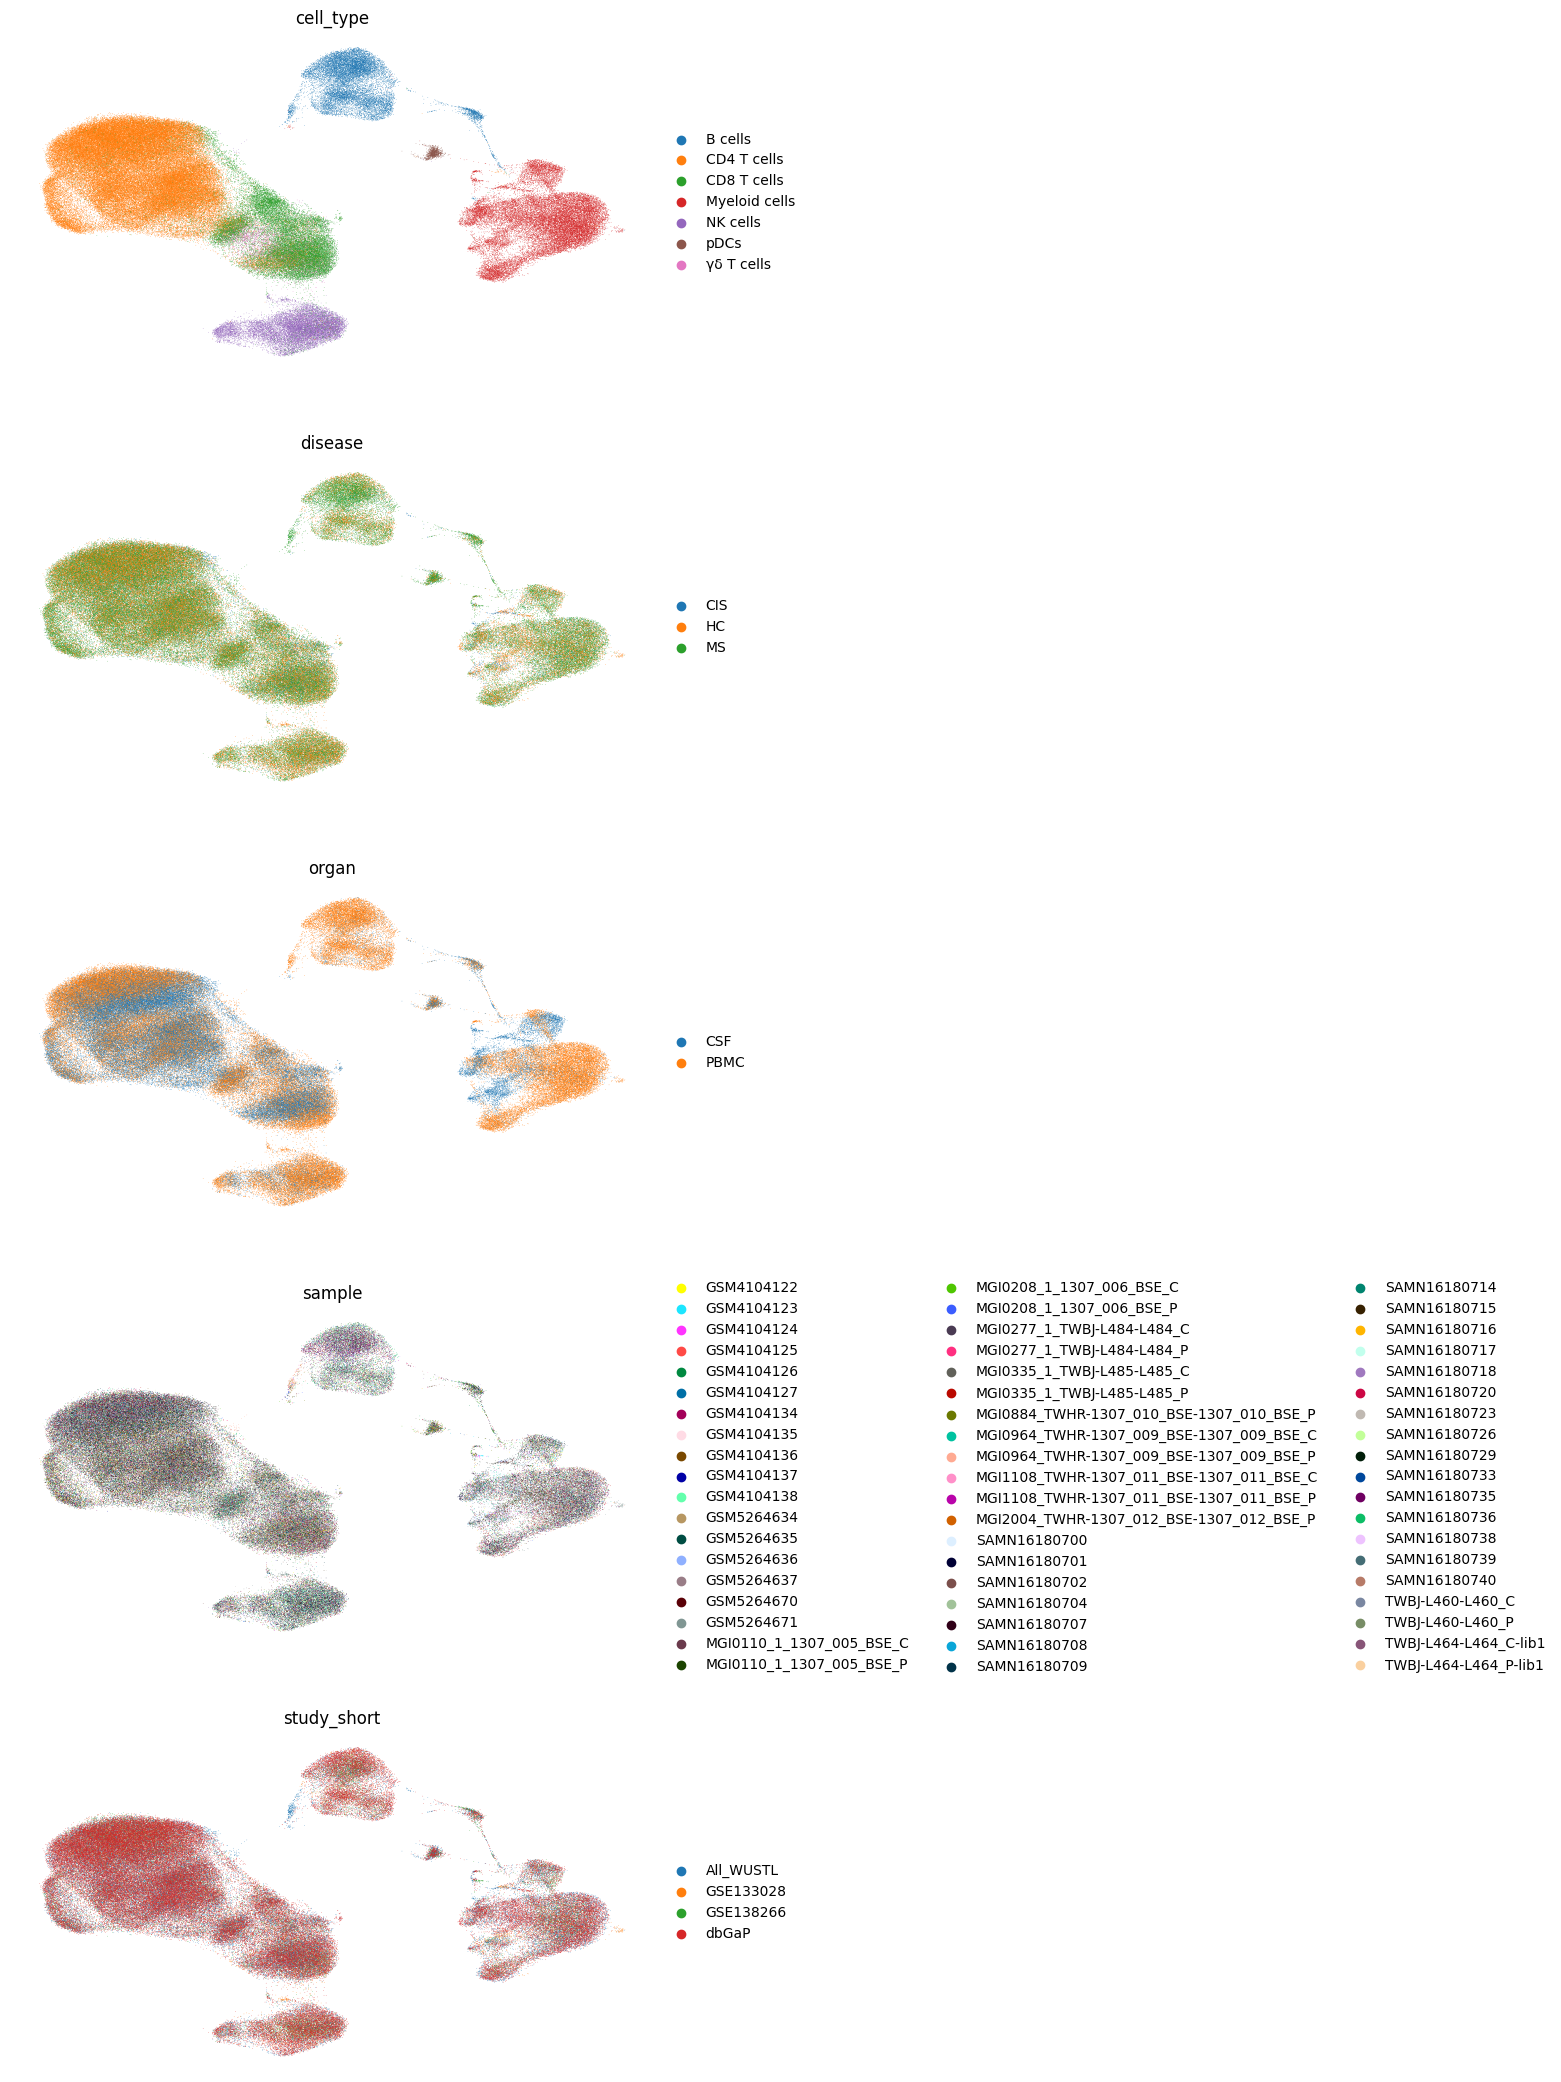

In [9]:
sc.pl.umap(adata, color=["cell_type", "disease", "organ", "sample", "study_short"], wspace=0.4, frameon=False, ncols=1)

In [ ]:
# Save processed data
os.makedirs("../data/processed/external/cantoni/annotated", exist_ok=True)
adata.write_h5ad("../data/processed/external/cantoni/annotated/cantoni_untreated_ms_hc.h5ad")